#### compare the genes that are regulated by specific regulators and present in iModulons

In [1]:
import pandas as pd
import os
from os import path

import matplotlib.pyplot as plt

from matplotlib_venn import venn2
from matplotlib_venn import venn2_circles


from pymodulon.io import *
from pymodulon.plotting import *

import os
from os import path

import pandas as pd

from matplotlib import cm, colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import plotly.express as px

In [2]:
# matplotlib default font
plt.rcParams['font.family'] = 'serif'
# Specify a preferred fallback list of fonts
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

### path to different data

In [3]:
data_dir = path.join('..', 'ctherm_nf','processed_data')
interim_dir = path.join('..', 'ctherm_nf', 'interim')
external_dir = path.join('..', 'ctherm_nf', 'external')

In [4]:
# load the data
ica_data = load_json_model(path.join(data_dir, 'ctherm.json.gz')) #adjusted

/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/p

In [5]:
df_enrichments = pd.read_csv(path.join(data_dir,'functional_enrichments.csv'), index_col=0)

### First rename the imodulon

In [6]:
df_rename_imod = pd.read_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t', index_col=0)

dict_rename_imod = df_rename_imod[['IM']].to_dict()['IM']

In [7]:
# rename all at once
ica_data.rename_imodulons(dict_rename_imod)

In [8]:
# set IM as index for this work
df_rename_imod.set_index('IM', inplace=True)

In [9]:
# GRN for regulation in C. thermocellum
for i,row in ica_data.imodulon_table.iterrows():
    if pd.notnull(row.regulator):
        ica_data.imodulon_table.loc[i, 'category'] = 'regulatory'
    else:
        ica_data.imodulon_table.loc[i, 'category'] = df_rename_imod.loc[i, 'category']

#### create data for the plot

In [10]:
df_reg = ica_data.imodulon_table.loc[~ica_data.imodulon_table.regulator.isna()]
df_reg = df_reg[['precision', 'recall', 'TP', 'regulon_size', 'imodulon_size']]

df_reg.rename(columns={'regulon_size': 'target_set_size'}, inplace=True)

df_reg['target_size_frac'] = df_reg['TP'].div(df_reg['target_set_size'])
df_reg['im_size_frac'] = df_reg['TP'].div(df_reg['imodulon_size'])
df_reg

,precision,recall,TP,target_set_size,imodulon_size,target_size_frac,im_size_frac
SigI6,0.241379,0.583333,7.0,12.0,29,0.583333,0.241379
BlaI_0696,0.150000,0.750000,3.0,4.0,20,0.750000,0.150000
GlyR3,0.428571,1.000000,3.0,3.0,7,1.000000,0.428571
Rex_2471,0.875000,0.071429,7.0,98.0,8,0.071429,0.875000


In [11]:
reg_interested = ['LexA_1449', 'TetR_0692']
df_reg_added = df_enrichments.loc[df_enrichments.annotation.isin(reg_interested)]

#
df_reg_added.set_index('imodulon', inplace=True)
df_reg_added = df_reg_added.loc[df_reg_added.index.isin([46, 54])]

In [12]:
df_reg_added

,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name
imodulon,,,,,,,,,,,,
46,TetR_0692,0.000202,0.003634,0.056338,0.228571,0.090395,8.0,35.0,142.0,GRN,NaN,NaN
54,LexA_1449,0.001370,0.024651,0.200000,0.054054,0.085106,4.0,74.0,20.0,GRN,NaN,NaN


In [13]:
# keep 46 and 54
for imod in df_reg_added.index.to_list():
    
    row_of_interest = df_reg_added.loc[imod]

    imod_name = row_of_interest['annotation']

    TP = row_of_interest['TP']
    precision = row_of_interest['precision']
    recall = row_of_interest['recall']
    reg_size = row_of_interest['target_set_size']
    imod_size = row_of_interest['imodulon_size']
    frac_reg = TP/reg_size
    frac_im = TP/imod_size
    
    df_reg.loc[imod_name] = precision, recall, TP, reg_size, imod_size, frac_reg, frac_im

In [14]:
df_reg

,precision,recall,TP,target_set_size,imodulon_size,target_size_frac,im_size_frac
SigI6,0.241379,0.583333,7.0,12.0,29.0,0.583333,0.241379
BlaI_0696,0.150000,0.750000,3.0,4.0,20.0,0.750000,0.150000
GlyR3,0.428571,1.000000,3.0,3.0,7.0,1.000000,0.428571
Rex_2471,0.875000,0.071429,7.0,98.0,8.0,0.071429,0.875000
TetR_0692,0.056338,0.228571,8.0,35.0,142.0,0.228571,0.056338
LexA_1449,0.200000,0.054054,4.0,74.0,20.0,0.054054,0.200000


## Comparing the imodulons

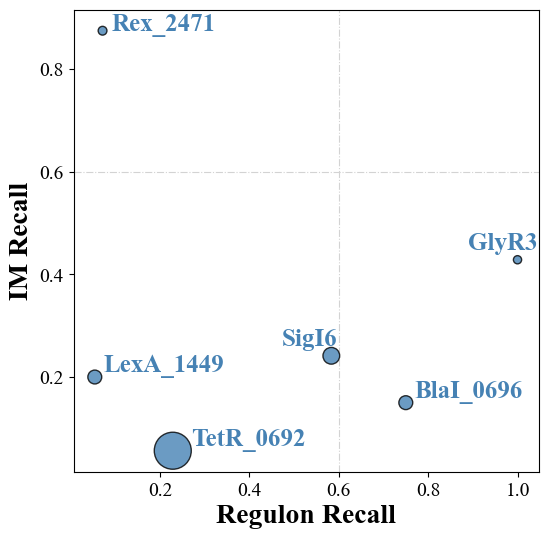

In [15]:
fig, ax = plt.subplots(figsize=(6,6))

#labels=['Amino acid metabolism', 'Antibiotics resistance', 'Biofilm', 'Carbon metabolism', 'Inorganic ion metabolism', 'Lipid metabolism', 'Motility', 'Nitrogen metabolism', 'Others', 'Quorum sensing', 'Secondary metabolites', 'Sulphur Metabolism']
# color = dict(zip(data.Function.unique(),['#D9A06A', '#63be79', '#46B8DE', '#E190D6', '#BDAC51',
#                                          '#00C19F', '#8FAAEB', '#ED8EB7', '#97B658', '#00C0C3',
#                                          '#C29BE9', '#E99491']))

# # add grid before scatter
# ax.grid(True, linestyle='-.', linewidth=1, color='lightgrey')

# ax.set_axisbelow(True) #make sure the axis is below
# # # add gridlines
# for pt in np.arange(0.2, 1.2, 0.2):
#     pt = np.round(pt, 2)
#     ax.axhline(pt, linestyle="-.", color='lightgrey', linewidth=0.8)
#     if pt < 1.0:
#         ax.axvline(pt, linestyle="-.", color='lightgrey', linewidth=0.8)

# threshold for IMs vs regulons
pt=0.6
ax.axhline(pt, linestyle="-.", color='lightgrey', linewidth=0.8)
ax.axvline(pt, linestyle="-.", color='lightgrey', linewidth=0.8)

ax.scatter(df_reg.recall, df_reg.precision,  s=df_reg.imodulon_size*5, 
                     c='steelblue',  alpha=0.8, edgecolors='black',
                     zorder=2) #zorder to make sure the points are above the gridlines

ax.set_xlabel("Regulon Recall", fontdict={'size':20, 'weight':'bold'})
ax.set_ylabel("IM Recall", fontdict={'size':20, 'weight':'bold'})




labels_of_interest = list() #any labels that I would like to keep
for t in ax.texts:
    if t.get_text() not in labels_of_interest:
        t.remove()

for imod, row in df_reg.iterrows():

    # default
    x_ax = row['recall'] + 0.02
    y_ax = row['precision'] + 0.01

    if imod in ['Rex_2471']:
        x_ax = row['recall'] + 0.02
        y_ax = row['precision']
    elif imod in ['TetR_0692']:
        x_ax = row['recall'] + 0.04
        y_ax = row['precision'] + 0.01
    elif imod in ['GlyR3', 'SigI6']:
            x_ax = row['recall'] - 0.11
            y_ax = row['precision'] + 0.02
        
    ax.text(x_ax, y_ax,
            imod, fontsize=18, fontweight='bold', color="steelblue")

ax.tick_params(labelsize=14)

plt.savefig('./results_characterize_imodulons/precision_recall_regulon_imodulon.png', transparent=True, pad_inches=0.01, dpi=300, format='png')
plt.show()

#### SigI6

In [15]:
imod_of_interest = 'Rex_2471'
df_genes_sigi6 = ica_data.view_imodulon(imod_of_interest).sort_values(by='gene_weight', ascending=False)
df_genes_sigi6


,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_1882,0.122600,nuoF,CP002416.1,NaN,2200217,2202010,-,NADH dehydrogenase (quinone),Energy production and conversion,UPI000038F991,Op1289,NaN,NaN,4Fe4S_Fe-S-bd;4Fe4S_Fe_S_CS;NADH-UbQ_OxRdtase_...,2Fe-2S_thioredx;Complex1_51K;Fer4;NADH_4Fe-4S;...,Rex_2471
Clo1313_0023,0.122388,RS00130,CP002416.1,NaN,24124,25059,+,thiamine pyrophosphate TPP-binding domain-cont...,Energy production and conversion,UPI000038F4FA,Op15,NaN,NaN,PorB-like;THDP-binding;TPP_enzyme_TPP-bd;,TPP_enzyme_C,Rex_2471
Clo1313_0020,0.117593,RS00115,CP002416.1,NaN,22030,22608,+,pyruvate/ketoisovalerate oxidoreductase%2C gam...,Energy production and conversion,UPI000038F4F8,Op15,NaN,NaN,Oxidoreductase_gamma_subunit;PorC_KorC;Pyrv/ke...,POR,Rex_2471
Clo1313_0021,0.113949,RS00120,CP002416.1,NaN,22605,22910,+,pyruvate ferredoxin/flavodoxin oxidoreductase%...,Energy production and conversion,UPI00003C8C4C,Op15,NaN,NaN,4Fe4S_Fe-S-bd;4Fe4S_Fe_S_CS;PorD_KorD;,Fer4,Rex_2471
Clo1313_0022,0.111778,porA,CP002416.1,NaN,22927,24111,+,pyruvate flavodoxin/ferredoxin oxidoreductase ...,Energy production and conversion,UPI0001B1F042,Op15,NaN,NaN,PFOR_II;Pyruvate:ferred/Flavod_OxRd;Pyrv_Fd/Fl...,PFOR_II;POR_N,Rex_2471
Clo1313_1881,0.108640,RS09510,CP002416.1,NaN,2198449,2200197,-,hydrogenase%2C Fe-only,Energy production and conversion,UPI0001B1ED41,Op1289,NaN,NaN,2Fe-2S_ferredoxin-like_sf;2Fe-2S_ferredoxin-ty...,Fe_hyd_SSU;Fe_hyd_lg_C;Fer2_4;Fer4;Fer4_7;Fer4...,Rex_2471
Clo1313_1883,0.104996,RS09520,CP002416.1,NaN,2202043,2202411,-,ferredoxin,Energy production and conversion,UPI000038F992,Op1289,NaN,NaN,Thioredoxin-like_sf;,2Fe-2S_thioredx,Rex_2471
Clo1313_2354,-0.105666,RS11945,CP002416.1,NaN,2764458,2765564,-,extracellular solute-binding protein family 1,Inorganic ion transport and metabolism,UPI000038F8A8,Op1612,NaN,NaN,Ferric-bd;SBP;,SBP_bac_6;SBP_bac_8,NaN


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


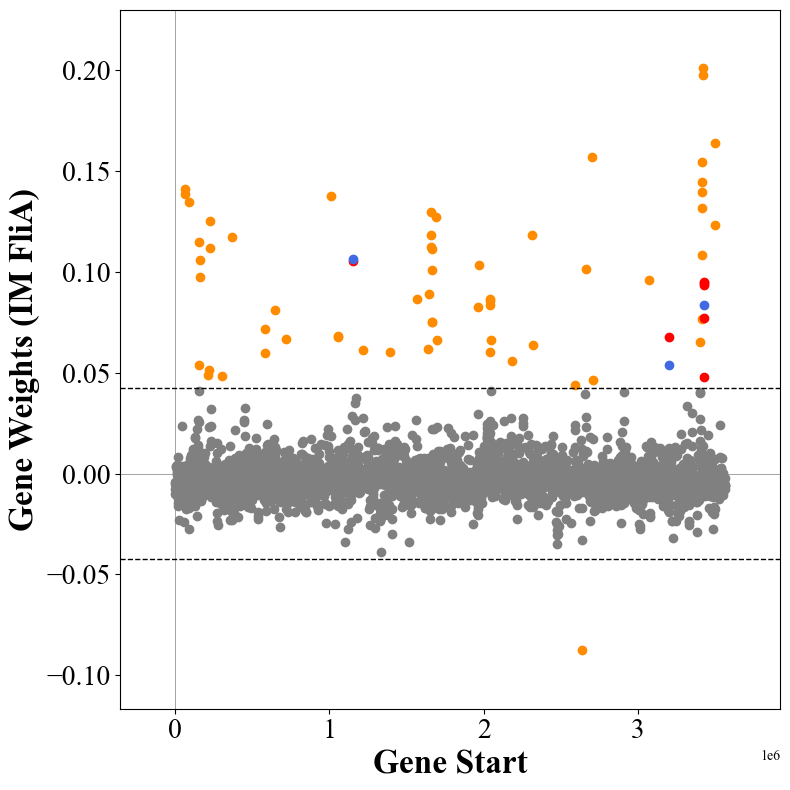

In [ ]:
# Example: list of genes you want to highlight
selected_genes = df_genes_flia.loc[df_genes_flia['COG'].isin(['Transcription'])].index.to_list()
others_in_imod = df_genes_flia.index.to_list()
others_in_imod = [k for k in others_in_imod if k not in selected_genes]

# Create a group label per gene
groups = pd.Series('not_in_imod', index=ica_data.M.index.to_list())
groups.loc[selected_genes] = 'selected'
groups.loc[others_in_imod] = 'not_transcription'
groups.loc[['Clo1313_0990', 'Clo1313_2717', 'Clo1313_2915', 'Clo1313_2916', 'Clo1313_2917', 'Clo1313_2918', 'Clo1313_2920']] = 'prob_selected'

# Define colors: grey for others, red for selected genes
colors = {
    'not_in_imod': 'grey',
    'not_transcription': 'darkorange',
    "prob_selected": "red",
    "selected": "royalblue",

}

# plt.figure(figsize=(10, 10))
ax = plot_gene_weights(ica_data, imod_of_interest, by='start', 
                        groups=groups,     # which genes are in which group
                        colors=colors,     # color mapping
                        show_labels=True, adjust_labels=True, legend=False)
                    
ax.set_ylabel(f'Gene Weights (IM {imod_of_interest})', fontdict={'weight':'bold', 'size':24})
ax.set_xlabel('Gene Start', fontdict={'weight':'bold', 'size':24})


labels_of_interest = [] #any labels that I would like to keep

for t in ax.texts:
    if t.get_text() not in labels_of_interest:
        t.remove()

ax.tick_params(axis='both', labelsize=20)
# ax.tick_params(axis='x', size=0)


# Get current figure object and modify its size
fig = plt.gcf() 
fig.set_size_inches(8, 8)

plt.tight_layout()
plt.show()


In [ ]:
df_genes_flia.loc['Clo1313_0990']

gene_weight                                               0.105351
gene_name                                                  RS05055
accession                                               CP002416.1
old_locus_tag                                                  NaN
start                                                      1153421
end                                                        1154599
strand                                                           +
gene_product      DegS sensor signal transduction histidine kinase
COG                                 Signal transduction mechanisms
uniprot                                              UPI0001B1ED09
operon                                                       Op675
GO_MF                                                          NaN
GO_BP                                                          NaN
InterPro         DegS;HATPase_C_sf;HATPase_dom;His_kinase_dom;S...
PFAMs                                       DegS;HATPase_c;His

In [ ]:
df_genes_flia

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_2909,0.201100,RS14785,CP002416.1,NaN,3416965,3417783,-,flagellin domain protein,Cell motility,UPI00017E1B09,Op1974,NaN,NaN,Flagellin;Flagellin_C;Flagellin_C_sub2;Flagell...,Flagellin_C;Flagellin_N,NaN
Clo1313_2910,0.197893,RS14790,CP002416.1,NaN,3417856,3418677,-,flagellin domain protein,Cell motility,UPI000038F96E,Op1975,NaN,NaN,Flagellin;Flagellin_C;Flagellin_C_sub2;Flagell...,Flagellin_C;Flagellin_N,NaN
Clo1313_2980,0.163938,RS15135,CP002416.1,NaN,3494068,3494490,+,hemerythrin-like metal-binding protein,Inorganic ion transport and metabolism,UPI00003C8B9F,Op2014,NaN,NaN,Hemerythrin;Hemerythrin-like;Hemerythrin-like_...,CheX;Hemerythrin,NaN
Clo1313_2290,0.157085,RS11630,CP002416.1,NaN,2697703,2698776,-,hypothetical protein,Carbohydrate transport and metabolism,UPI0000537D74,Op1581,NaN,NaN,Cu_amine_oxidase-like_N;,Cu_amine_oxidN1;NLPC_P60,NaN
Clo1313_2907,0.154665,RS14775,CP002416.1,NaN,3414590,3414973,-,hypothetical protein,No COG annotation,UPI000038F971,Op1973,NaN,NaN,DUF8042;,-,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Clo1313_0279,0.048217,RS15960,CP002416.1,NaN,304439,304609,+,conserved hypothetical protein,No COG annotation,UPI00003C8F99,Op186,NaN,NaN,Spo0E-like_sf;,-,NaN
Clo1313_2920,0.048153,RS14840,CP002416.1,NaN,3426999,3427442,-,regulatory protein%2C MerR,Cell motility,UPI0000533B97,Op1981,NaN,NaN,NaN,-,NaN
Clo1313_2298,0.046200,RS11675,CP002416.1,NaN,2706854,2708491,-,hypothetical protein,No COG annotation,UPI000038FD98,Op1585,NaN,NaN,NaN,NaN,NaN
Clo1313_2194,0.044070,RS11115,CP002416.1,NaN,2588821,2589285,-,CheW protein,Cell motility,UPI0001B1EFB8,Op1516,NaN,NaN,CheW;CheW-like_dom_sf;CheW-lke_dom;,CheW,NaN


In [ ]:
df_genes_flia.loc[df_genes['COG'].isin(['Transcription'])]

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_0991,0.106604,RS05060,CP002416.1,NaN,1154592,1155242,+,two component transcriptional regulator%2C Lux...,Transcription,UPI000038F690,Op675,NaN,NaN,CheY-like_superfamily;NreC/VraR/RcsB-like_REC;...,GerE;Response_reg,AraC_0222
Clo1313_2919,0.083526,flgM,CP002416.1,NaN,3426473,3426766,-,Anti-sigma-28 factor FlgM family protein,Transcription,UPI00003C8CDE,Op1980,NaN,NaN,Anti-sigma-28_factor_FlgM_sf;FlgM;FlgM_C;,FlgM,NaN
Clo1313_2716,0.053858,sigH,CP002416.1,NaN,3195941,3196585,-,RNA polymerase%2C sigma-24 subunit%2C ECF subf...,Transcription,UPI0000537743,Op1832,NaN,NaN,RNA_pol_sigma-70_dom;RNA_pol_sigma-H;RNA_pol_s...,GerE;Sigma70_r2;Sigma70_r4_2,NaN


In [ ]:
FliA-FlgM

In [ ]:
ica_data.gene_table.loc['Clo1313_1725']

gene_name                                                  RS08725
accession                                               CP002416.1
old_locus_tag                                                  NaN
start                                                      2020402
end                                                        2021172
strand                                                           -
gene_product       RNA polymerase%2C sigma 28 subunit%2C FliA/WhiG
COG                                                  Transcription
uniprot                                              UPI0001B1EEA2
operon                                                      Op1195
GO_MF                                                          NaN
GO_BP                                                          NaN
InterPro         RNA_pol_sigma-70_dom;RNA_pol_sigma70;RNA_pol_s...
PFAMs                             Sigma70_r2;Sigma70_r3;Sigma70_r4
regulator                                                     

In [ ]:
df_genes_of_interest = df_genes_flia.loc[df_genes_flia['COG'].isin(['Transcription'])]
df_genes_of_interest

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_0991,0.106604,RS05060,CP002416.1,NaN,1154592,1155242,+,two component transcriptional regulator%2C Lux...,Transcription,UPI000038F690,Op675,NaN,NaN,CheY-like_superfamily;NreC/VraR/RcsB-like_REC;...,GerE;Response_reg,AraC_0222
Clo1313_2919,0.083526,flgM,CP002416.1,NaN,3426473,3426766,-,Anti-sigma-28 factor FlgM family protein,Transcription,UPI00003C8CDE,Op1980,NaN,NaN,Anti-sigma-28_factor_FlgM_sf;FlgM;FlgM_C;,FlgM,NaN
Clo1313_2716,0.053858,sigH,CP002416.1,NaN,3195941,3196585,-,RNA polymerase%2C sigma-24 subunit%2C ECF subf...,Transcription,UPI0000537743,Op1832,NaN,NaN,RNA_pol_sigma-70_dom;RNA_pol_sigma-H;RNA_pol_s...,GerE;Sigma70_r2;Sigma70_r4_2,NaN


In [ ]:
## check which genes are correlated to the activity

# which genes are correlated
genes_of_interest = df_genes_of_interest.index.to_list()
genes_of_interest.append('Clo1313_0990')

df_metadata = ica_data.sample_table
df_expression = ica_data.X

df_corr_genes = pd.DataFrame(columns=['locus_tag', 'COG', 'Corr'])

for loctag_interest in genes_of_interest:
    # df_metadata_eh = df_metadata.loc[df_metadata.project.isin([proj])]
    df_metadata_eh = df_metadata.copy()
    # df_metadata_eh = df_metadata_eh.loc[~(df_metadata_eh['condition']=='wt_nlim')] #don't have information on this
    exp_of_interest = df_metadata_eh.index.to_list()
    df_expression_eh = df_expression[exp_of_interest]
    values = df_expression_eh.loc[loctag_interest, :]

    x = values
    y = ica_data.A[exp_of_interest].loc[imod_of_interest]

    corr, p = pearsonr(x,y)
    corr, p = np.round(corr, 2), np.round(p, 2)

    if np.abs(corr) >= 0.7 and p<0.05:
        df_corr_genes.loc[len(df_corr_genes)] = loctag_interest, df_genes_flia.loc[loctag_interest, 'COG'], corr
        # print(loctag_interest, df_genes_flia.loc[loctag_interest].gene_product, , p)

df_corr_genes.set_index('locus_tag', inplace=True)
df_corr_genes = pd.concat([df_corr_genes, df_genes_flia], axis=1, join='inner')
df_corr_genes

,COG,Corr,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_0991,Transcription,0.91,0.106604,RS05060,CP002416.1,NaN,1154592,1155242,+,two component transcriptional regulator%2C Lux...,Transcription,UPI000038F690,Op675,NaN,NaN,CheY-like_superfamily;NreC/VraR/RcsB-like_REC;...,GerE;Response_reg,AraC_0222
Clo1313_2919,Transcription,0.82,0.083526,flgM,CP002416.1,NaN,3426473,3426766,-,Anti-sigma-28 factor FlgM family protein,Transcription,UPI00003C8CDE,Op1980,NaN,NaN,Anti-sigma-28_factor_FlgM_sf;FlgM;FlgM_C;,FlgM,NaN
Clo1313_2716,Transcription,0.75,0.053858,sigH,CP002416.1,NaN,3195941,3196585,-,RNA polymerase%2C sigma-24 subunit%2C ECF subf...,Transcription,UPI0000537743,Op1832,NaN,NaN,RNA_pol_sigma-70_dom;RNA_pol_sigma-H;RNA_pol_s...,GerE;Sigma70_r2;Sigma70_r4_2,NaN
Clo1313_0990,Signal transduction mechanisms,0.95,0.105351,RS05055,CP002416.1,NaN,1153421,1154599,+,DegS sensor signal transduction histidine kinase,Signal transduction mechanisms,UPI0001B1ED09,Op675,NaN,NaN,DegS;HATPase_C_sf;HATPase_dom;His_kinase_dom;S...,DegS;HATPase_c;HisKA_3,AraC_0222


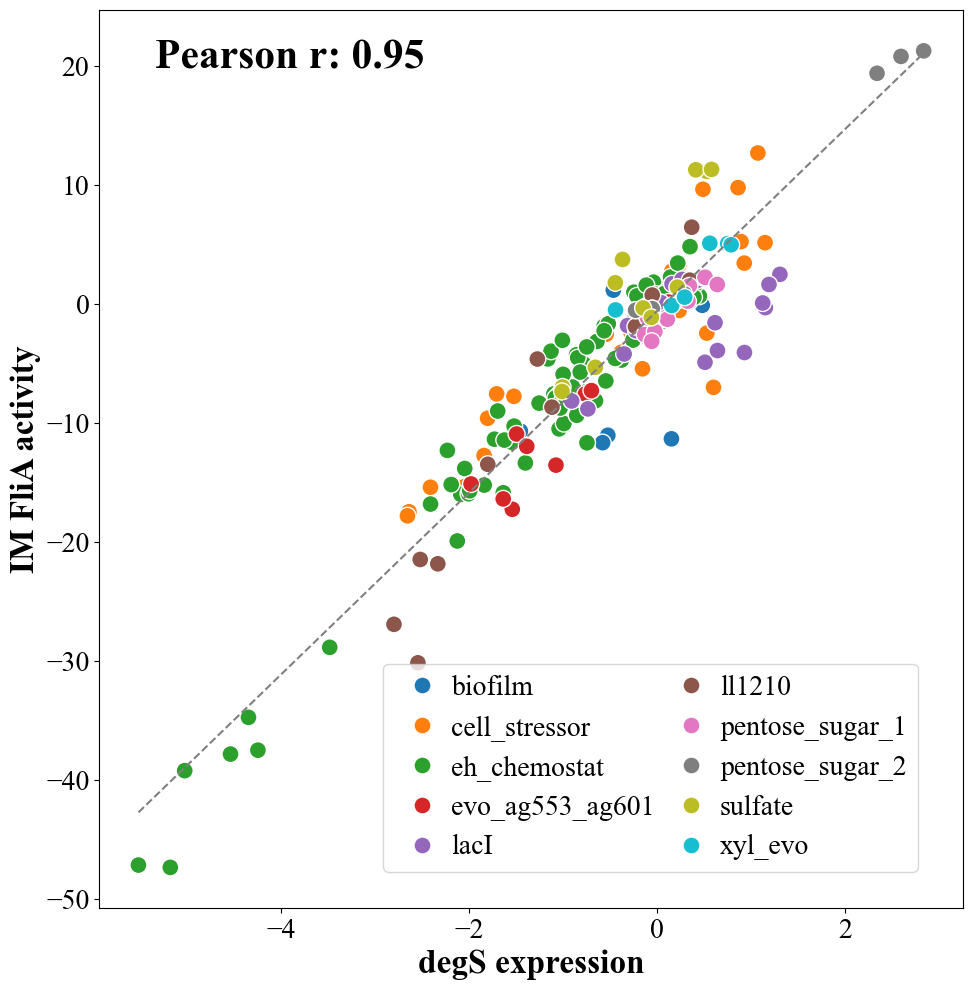

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gene_of_interest = 'Clo1313_0990' 

df_activity = ica_data.A
df_activity = df_activity.T
df_metadata = ica_data.sample_table
df_expression = ica_data.X
df_expression = df_expression.T

df_metadata_sel = df_metadata.copy()#loc[df_metadata.project.isin(['cell_stressor', 'lacI'])]
df_expression_sel = df_expression.loc[df_metadata_sel.index.to_list()]
df_activity_sel = df_activity.loc[df_metadata_sel.index.to_list()]

# only need certain genes and imod
df_expression_sel = df_expression_sel[gene_of_interest]
df_activity_sel = df_activity_sel[imod_of_interest]

# concat
df_expression_activity_sel = pd.concat([df_expression_sel, df_activity_sel], axis=1)
# add condtion
for idx in df_expression_activity_sel.index.to_list():
    df_expression_activity_sel.loc[idx, 'condition'] = df_metadata.loc[idx, 'condition']
    df_expression_activity_sel.loc[idx, 'project'] = df_metadata.loc[idx, 'project']

sns.scatterplot(x=gene_of_interest, y=imod_of_interest, data=df_expression_activity_sel, s=150, hue='project', palette='tab10', ax=ax)#, legend=None)

ax.set_ylabel(f'IM {imod_of_interest} activity', fontdict={'weight':'bold', 'size':24})
ax.set_xlabel(f'degS expression', fontdict={'weight':'bold', 'size':24})

ax.tick_params(axis='both', labelsize=20)
# ax.tick_params(axis='x', size=0)

x = df_expression_activity_sel[gene_of_interest]
y = df_expression_activity_sel[imod_of_interest]
# Create data for perfect positive correlation
m, b = np.polyfit(x, y, 1)  # degree-1 polynomial = linear fit [web:134][web:137]
# 3. Build x-range and plot the regression line
x_line = np.linspace(np.min(x), np.max(x), 100)
ax.plot(x_line, m * x_line + b,
        linestyle='--', color='gray', linewidth=1.5)


# legend
plt.legend(bbox_to_anchor=(0.3, 0.3), borderaxespad=0.9, columnspacing=0.3, handletextpad=0.05, fontsize=20, ncol=2)

# # Get current figure object and modify its size
# fig = plt.gcf() 
# fig.set_size_inches(8, 8)

# for text placement
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(x=xlim[0]-0.1*xlim[0], y=ylim[1]-0.2*ylim[1], s=f'Pearson r: 0.95', fontdict={'weight': 'bold', 'fontsize':30})

plt.tight_layout()
plt.show()




# plt.show()

### compare activities to different iMods

In [ ]:
df_activity = ica_data.A
df_activity = df_activity.T

df_metadata = ica_data.sample_table
df_expression = ica_data.X
df_expression = df_expression.T

In [ ]:
df_activity_corr = df_activity.corr()
df_activity_corr_flia = df_activity_corr[imod_of_interest]

# df_activity_corr_flia = df_activity_corr_flia.abs().sort_values(ascending=False)

<Axes: xlabel='FliA iModulon Activity', ylabel='SwrA iModulon Activity'>

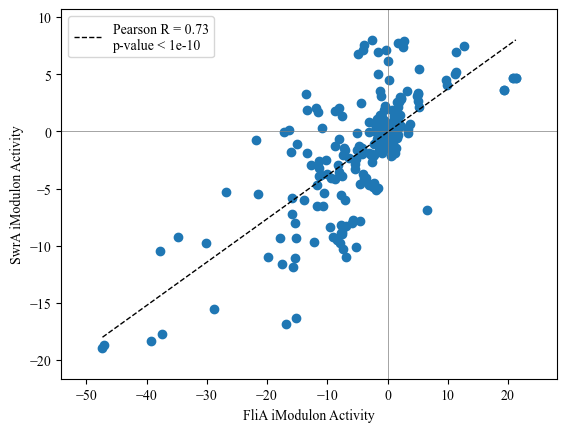

In [ ]:
compare_activities(ica_data, 'FliA', 'SwrA')

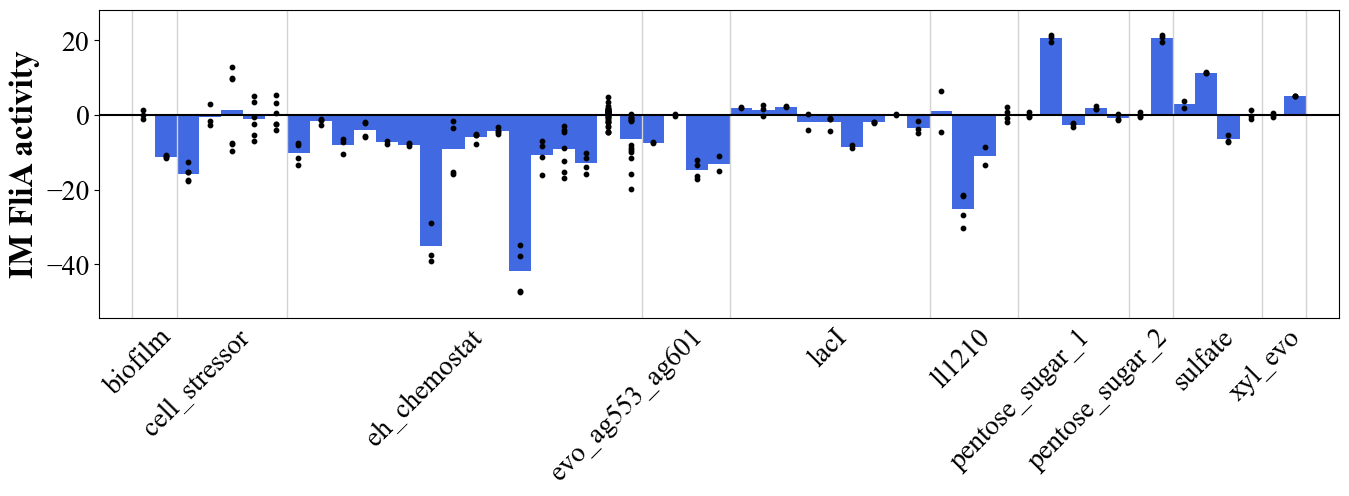

In [ ]:
ax = plot_activities(ica_data, imod_of_interest)#, projects=['eh_chemostat'])

# Loop through the axes patches to change colors
for bar in ax.patches:
    bar.set_facecolor('royalblue')

ax.tick_params(axis='y', labelsize=20)

ax.set_ylabel(f'IM {imod_of_interest} activity', fontdict={'weight':'bold', 'size': 24})

# increase text size for projects
# Loop through only the manually added text boxes
for txt in ax.texts:
    txt.set_fontsize(20)

fig = plt.gcf() 
fig.set_size_inches(16, 4)

In [ ]:
data = ica_data.imodulon_table.copy()
data = pd.merge(data, df_en


# df_enrichments.loc[df_enrichments.annotation.isin([k for k in dict_rename_imod.values()])]

In [39]:
df_enrichments

,imodulon,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name
0,2,L-tryptophan biosynthesis,2.510499e-11,4.744843e-09,0.800000,0.666667,0.727273,4.0,6.0,5.0,biocyc,NaN,NaN
1,7,"(1,4)-&beta;-D-xylan degradation",9.408885e-04,8.891397e-02,0.068966,0.400000,0.117647,2.0,5.0,29.0,biocyc,NaN,NaN
2,7,cellulose and hemicellulose degradation (cellu...,9.408885e-04,8.891397e-02,0.068966,0.400000,0.117647,2.0,5.0,29.0,biocyc,NaN,NaN
3,10,fatty acid biosynthesis initiation (type II),6.927798e-07,1.309354e-04,0.230769,0.600000,0.333333,3.0,5.0,13.0,biocyc,NaN,NaN
4,10,even <i>iso</i>-branched-chain fatty acid bios...,3.849618e-06,3.637889e-04,0.230769,0.375000,0.285714,3.0,8.0,13.0,biocyc,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,48,GlyR3,5.510798e-05,9.919436e-04,0.153846,0.666667,0.250000,2.0,3.0,13.0,GRN,NaN,NaN
10,49,GlyR2,5.177310e-03,9.319158e-02,0.100000,0.085714,0.092308,3.0,35.0,30.0,GRN,NaN,NaN
11,54,LexA_1449,1.369519e-03,2.465135e-02,0.200000,0.054054,0.085106,4.0,74.0,20.0,GRN,NaN,NaN
12,56,GlyR3,8.521977e-09,1.533956e-07,0.428571,1.000000,0.600000,3.0,3.0,7.0,GRN,NaN,NaN


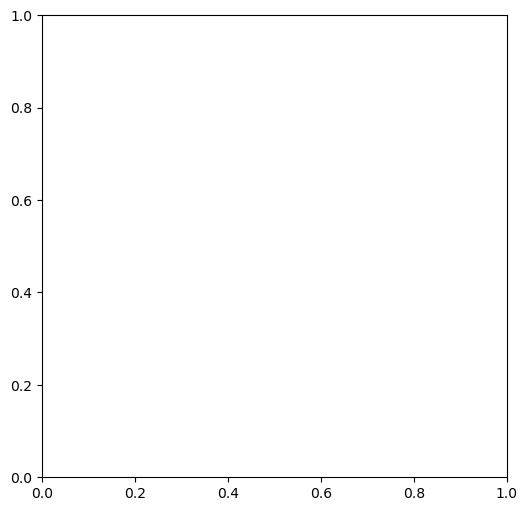

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

#labels=['Amino acid metabolism', 'Antibiotics resistance', 'Biofilm', 'Carbon metabolism', 'Inorganic ion metabolism', 'Lipid metabolism', 'Motility', 'Nitrogen metabolism', 'Others', 'Quorum sensing', 'Secondary metabolites', 'Sulphur Metabolism']
color = dict(zip(ica_data.imodulon_table.category.unique(),['#D9A06A', '#63be79', '#46B8DE', '#E190D6', '#BDAC51',
                                         '#00C19F']))#, '#8FAAEB', '#ED8EB7', '#97B658', '#00C0C3',
                                         #'#C29BE9', '#E99491']))

scatter = ax.scatter(data.recall, data.precision,  s=data.updated_size, 
                     c=data.colors,  alpha=0.7, edgecolors='black',)

# col_legend = []
# for i in color:
#     col_legend.append(mpatches.Patch(color=color[i], label=i))

# plt.legend( handles=col_legend,bbox_to_anchor=(0.99,1.0), fontsize=12)

# #plt.grid(True)
# plt.xlabel("regulon recall", size=14)
# plt.ylabel("iModulon recall", size=14)
# ynew = 0.6
# ax.axhline(ynew, linestyle="-.", color='gray', linewidth=0.5)
# xnew = 0.6
# ax.axvline(xnew, linestyle="-.", color='gray', linewidth=0.5)



In [19]:
ica_data.imodulon_table.loc['TetR_0692']

regulator                    NaN
pvalue                       NaN
qvalue                       NaN
precision                    NaN
recall                       NaN
f1score                      NaN
TP                           NaN
regulon_size                 NaN
imodulon_size                142
n_regs                       NaN
explained_variance      0.015212
single_gene                  NaN
category              regulatory
Name: TetR_0692, dtype: object

In [18]:
ica_data.imodulon_table.loc[~ica_data.imodulon_table.regulator.isna()]

,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs,explained_variance,single_gene,category
SigI6,Sigma-16,3.426805e-12,3.426805e-11,0.241379,0.583333,0.341463,7.0,12.0,29,1.0,0.009637,NaN,regulatory
BlaI_0696,BlaI_0696,1.105424e-06,5.527119e-06,0.150000,0.750000,0.250000,3.0,4.0,20,1.0,0.004403,NaN,regulatory
GlyR3,GlyR3,8.521977e-09,1.704395e-08,0.428571,1.000000,0.600000,3.0,3.0,7,1.0,0.002189,True,regulatory
Rex_2471,Rex_2471,3.084941e-10,3.084941e-10,0.875000,0.071429,0.132075,7.0,98.0,8,1.0,0.009379,NaN,regulatory


### mapping files

In [16]:
# map locus_tag to gene names
df_go_curated = pd.read_csv('../ctherm_nf/external/GO_annotations_curated.csv', index_col=0)

df_go_curated_grouped = df_go_curated.groupby('gene_id')['gene_name'].apply(set)


# gene name from manually curated data
# Load the Excel file object
xls_file = os.path.join('..', 'ctherm_nf', 'external', 'manual_curation_GRN.xlsx')
xls = pd.ExcelFile(xls_file)

# Get list of sheet names
sheet_names = xls.sheet_names

df_grn_manual = pd.DataFrame(columns=['locus_tag', 'gene_name'])
for sheet in sheet_names:
    df = pd.read_excel(xls_file, sheet_name=sheet)
    df = df[['locus_tag', 'gene_name']]
    df_grn_manual = pd.concat([df_grn_manual, df], join='outer')

df_grn_manual.drop_duplicates(keep='first', inplace=True)
df_grn_manual.set_index('locus_tag', inplace=True)

### actual imodulon computations

In [80]:
imod_of_interest = 'LexA_1449'

df_obs = pd.read_csv('../ctherm_nf/external/GRN_curated.csv', index_col=0)
df_imod = pd.read_csv(f'./{imod_of_interest}/{imod_of_interest}_gene_weights.tsv', sep='\t', index_col=0)
df_imod

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,regulator
Clo1313_0114,0.234944,RS00605,CP002416.1,NaN,129323,130393,+,sulfate ABC transporter%2C periplasmic sulfate...,Inorganic ion transport and metabolism,UPI0000F2192F,Op82,NaN
Clo1313_0115,0.230773,cysT,CP002416.1,NaN,130418,131266,+,sulfate ABC transporter%2C inner membrane subu...,Inorganic ion transport and metabolism,UPI00017E2FB4,Op82,NaN
Clo1313_0116,0.263112,cysW,CP002416.1,NaN,131353,132237,+,sulfate ABC transporter%2C inner membrane subu...,Inorganic ion transport and metabolism,UPI00003C8AEF,Op82,NaN
Clo1313_0117,0.257471,RS00620,CP002416.1,NaN,132280,133344,+,sulfate ABC transporter%2C ATPase subunit,Inorganic ion transport and metabolism,UPI000038F759,Op83,NaN
Clo1313_0118,0.230644,RS00625,CP002416.1,NaN,133412,134131,+,adenylylsulfate reductase%2C thioredoxin depen...,Amino acid transport and metabolism,UPI00017E2FB3,Op84,Fur_1691
Clo1313_0119,0.172653,RS00630,CP002416.1,NaN,134419,135300,+,phosphoadenosine phosphosulfate reductase,Amino acid transport and metabolism,UPI0000533E13,Op84,LexA_1449
Clo1313_0120,0.221308,RS00635,CP002416.1,NaN,135302,137101,+,sulfate adenylyltransferase%2C large subunit,Coenzyme transport and metabolism,UPI000038F75C,Op84,LexA_1449
Clo1313_0121,0.261516,thiS,CP002416.1,NaN,137120,137329,+,thiamine biosynthesis protein ThiS,Coenzyme transport and metabolism,UPI0001B1F07F,Op84,LexA_1449
Clo1313_0122,0.224655,moeB,CP002416.1,NaN,137326,138138,+,UBA/THIF-type NAD/FAD binding protein,Coenzyme transport and metabolism,UPI000038F75E,Op84,LexA_1449
Clo1313_0123,0.235815,RS00650,CP002416.1,NaN,138162,138581,+,Mov34/MPN/PAD-1 family protein,Function unknown,UPI00003C8AF1,Op84,LexA_1449


In [68]:
df_imod['locus_tag'] = df_imod.index.to_list()
df_operons = df_imod.groupby('operon')['locus_tag'].apply(list)

df_operons

operon
Op254                                       [Clo1313_0390]
Op255           [Clo1313_0391, Clo1313_0392, Clo1313_0393]
Op82            [Clo1313_0114, Clo1313_0115, Clo1313_0116]
Op83                                        [Clo1313_0117]
Op84     [Clo1313_0118, Clo1313_0119, Clo1313_0120, Clo...
Name: locus_tag, dtype: object

In [69]:
df_operons.loc['Op84']

['Clo1313_0118',
 'Clo1313_0119',
 'Clo1313_0120',
 'Clo1313_0121',
 'Clo1313_0122',
 'Clo1313_0123',
 'Clo1313_0124',
 'Clo1313_0125']

In [73]:
df_obs_interest = df_obs.loc[df_obs.regulator==imod_of_interest]
genes_obs_of_interest = set(df_obs_interest['gene_id'].to_list())
genes_pred_of_interest = set(df_imod.index.to_list())

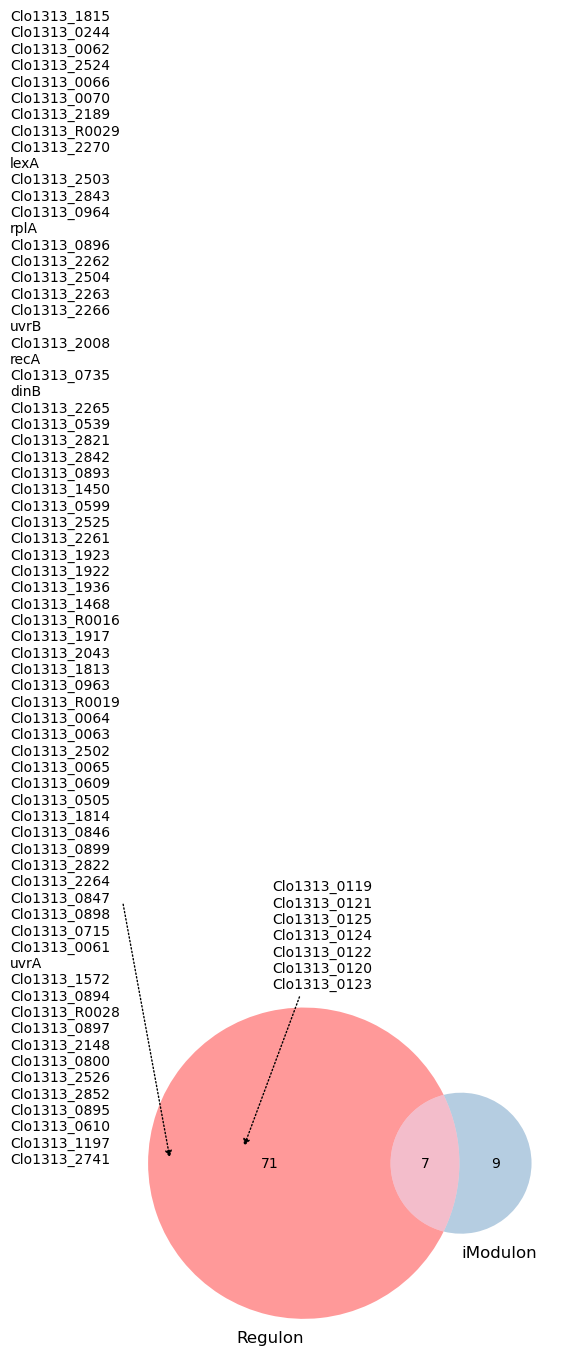

In [84]:
dict_genes_not_in_obs, _, genes_not_in_predicted = create_venn_diagram(genes_obs_of_interest, genes_pred_of_interest, df_grn_manual, df_go_curated_grouped, imod_of_interest)

In [85]:
dict_genes_not_in_obs

{'Clo1313_0115': 'Clo1313_0115',
 'Clo1313_0391': 'Clo1313_0391',
 'Clo1313_0118': 'Clo1313_0118',
 'Clo1313_0392': 'Clo1313_0392',
 'Clo1313_0114': 'Clo1313_0114',
 'Clo1313_0116': 'Clo1313_0116',
 'Clo1313_0117': 'Clo1313_0117',
 'Clo1313_0393': 'Clo1313_0393',
 'Clo1313_0390': 'Clo1313_0390'}

In [83]:
get_gene_names(genes_not_in_observed, df_grn_manual, df_go_curated_grouped, return_type='dict')

{'Clo1313_0119': 'Clo1313_0119',
 'Clo1313_0121': 'Clo1313_0121',
 'Clo1313_0125': 'Clo1313_0125',
 'Clo1313_0124': 'Clo1313_0124',
 'Clo1313_0122': 'Clo1313_0122',
 'Clo1313_0120': 'Clo1313_0120',
 'Clo1313_0123': 'Clo1313_0123'}

### FIN